In [30]:
import numpy as np
import pandas as pd
import idx2numpy
import matplotlib.pyplot as plt

In [31]:

#mnist (easy)  99.smth % accuracy
'''
train_img = ('./data/train-images.idx3-ubyte')
train_labels = ('./data/train-labels.idx1-ubyte')
test_img = ('./data/t10k-images.idx3-ubyte')
test_labels = ('./data/t10k-labels.idx1-ubyte')
'''
#funky mnist  89-90% accuracy  CNN with pytorch reaches 92 when naively implemented

train_img = ('./fashion/train-images-idx3-ubyte')
train_labels = ('./fashion/train-labels-idx1-ubyte')
test_img = ('./fashion/t10k-images-idx3-ubyte')
test_labels = ('./fashion/t10k-labels-idx1-ubyte')

X = idx2numpy.convert_from_file(train_img)
y = idx2numpy.convert_from_file(train_labels)

X_test = idx2numpy.convert_from_file(test_img)
y_test = idx2numpy.convert_from_file(test_labels)

X = np.reshape(X,(X.shape[0],784))
X_test = np.reshape(X_test,(X_test.shape[0],784))

X = X / 255.0
X_test = X_test / 255.0
mean = X.mean()
std = X.std()
X = (X - mean) / std
X_test = (X_test - mean) / std  #must be X mean not test mean so they are in the same Z units  upsie

print("Training images:", X.shape)
print("Training labels:", y.shape)

print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)





Training images: (60000, 784)
Training labels: (60000,)
Test images: (10000, 784)
Test labels: (10000,)


In [32]:
def initialize():

    #(output,input) shape
    w1 = np.random.randn(256,784) * np.sqrt(2/784)
    b1 = np.zeros((256,1))
    w2 = np.random.randn(128,256) * np.sqrt(2/256) 
    b2 = np.zeros((128,1))
    w3 = np.random.randn(128,128) * np.sqrt(2/128)
    b3 = np.zeros((128,1))
    w4 = np.random.randn(64,128) * np.sqrt(2/128)
    b4 = np.zeros((64,1))
    w5 = np.random.randn(10,64) * np.sqrt(2/64)
    b5 = np.zeros((10,1))

    return w1,w2,w3,w4,w5,b1,b2,b3,b4,b5


def ReLU(Z):
    return np.maximum(0, Z)

def ReLU_derivative(Z):
    return (Z > 0).astype(float)

def softmax(Z):
    Z = Z - np.max(Z,axis=0,keepdims=True)
    return np.exp(Z) / np.sum(np.exp(Z),axis=0,keepdims=True)

def one_hot(Y):
    onehot = np.zeros((Y.shape[0],10))
    onehot[np.arange(Y.shape[0]),Y] = 1
    return onehot.T

def get_predictions(a5):
    return np.argmax(a5, axis=0) #axis changes with (input, output) data shape

def validate(prediction,y):
    return np.mean(prediction == y)

def loss(a5,y):
    return np.sum(-np.sum(y * np.log(a5),axis=0))

In [33]:
def forward_pass(w1,b1,w2,b2,w3,b3,w4,b4,w5,b5,X):
    z1 = w1 @ X.T + b1
    a1 = ReLU(z1) 
    z2 = w2 @ a1 + b2
    a2 = ReLU(z2) 
    z3 = w3 @ a2 + b3
    a3 = ReLU(z3) 
    z4 = w4 @ a3 + b4
    a4 = ReLU(z4)
    z5 = w5 @ a4 + b5
    a5 = softmax(z5) 

    return z1,a1,z2,a2,z3,a3,z4,a4,z5,a5

def back_propagation(w2,w3,w4,w5,a1,a2,a3,a4,a5,z1,z2,z3,z4,X,Y): 
    m = Y.shape[1]
    #applied chain rule starting from 
    # ∂L/∂z5 =  ∂L/∂a5* ∂a5/∂z5 = a5 - Y
    dz5 = a5 - Y
    dw5 = (1/m) * dz5 @ a4.T
    db5 = (1/m) * np.sum(dz5, axis=1, keepdims=True)

    dz4 = (w5.T @ dz5) * ReLU_derivative(z4)
    dw4 = (1/m) * dz4 @ a3.T
    db4 = (1/m) * np.sum(dz4, axis=1, keepdims=True)

    dz3 = (w4.T @ dz4) * ReLU_derivative(z3)
    dw3 = (1/m) * dz3 @ a2.T
    db3 = (1/m) * np.sum(dz3, axis=1, keepdims=True)

    dz2 = (w3.T @ dz3) * ReLU_derivative(z2)
    dw2 = (1/m) * dz2 @ a1.T
    db2 = (1/m) * np.sum(dz2, axis=1,keepdims=True)

    dz1 = (w2.T @ dz2) * ReLU_derivative(z1)
    dw1 = (1/m) * dz1 @ X
    db1 = (1/m) * np.sum(dz1, axis=1,keepdims=True)

    return dw1,dw2,dw3,dw4,dw5,db1,db2,db3,db4,db5

def update_params(
        w1,w2,w3,w4,w5,
        dw1,dw2,dw3,dw4,dw5,
        b1,b2,b3,b4,b5,
        db1,db2,db3,db4,db5,
        alpha
        ):
    w1 -= alpha * dw1
    w2 -= alpha * dw2
    w3 -= alpha * dw3
    w4 -= alpha * dw4
    w5 -= alpha * dw5

    b1 -= alpha * db1
    b2 -= alpha * db2
    b3 -= alpha * db3
    b4 -= alpha * db4
    b5 -= alpha * db5

    return w1,w2,w3,w4,w5,b1,b2,b3,b4,b5

In [34]:
def SGD(w1,w2,w3,w4,w5,b1,b2,b3,b4,b5,X,Y,iterations=500,batch_size=64,alpha=0.004): 
    permutation = np.random.permutation(X.shape[0])
    for i in range(iterations):
        X_batch = X[permutation[i*batch_size:(i+1)*batch_size]]
        Y_batch = Y[:,permutation[i*batch_size:(i+1)*batch_size]]

        z1,a1,z2,a2,z3,a3,z4,a4,_,a5 = forward_pass(
            w1,b1,w2,b2,w3,b3,w4,b4,w5,b5,X_batch
            )
        
        dw1,dw2,dw3,dw4,dw5,db1,db2,db3,db4,db5 = back_propagation(
            w2,w3,w4,w5,a1,a2,a3,a4,a5,z1,z2,z3,z4,X_batch,Y_batch
            )
        
        w1,w2,w3,w4,w5,b1,b2,b3,b4,b5 = update_params(
            w1,w2,w3,w4,w5,
            dw1,dw2,dw3,dw4,dw5,
            b1,b2,b3,b4,b5,
            db1,db2,db3,db4,db5,
            alpha
        )
    return w1,w2,w3,w4,w5,b1,b2,b3,b4,b5,a5
        


In [ ]:
def train_model(X,y,X_test,y_test,batch_size=64,alpha=0.004,epochs=100):
    Y_hot = one_hot(y)
    y_hot = one_hot(y_test)

    w1,w2,w3,w4,w5,b1,b2,b3,b4,b5 = initialize()
    for i in range(epochs):
        if i > 80:
            alpha = 0.004
        w1,w2,w3,w4,w5,b1,b2,b3,b4,b5,a5 = SGD(
            w1,w2,w3,w4,w5,b1,b2,b3,b4,b5,X,Y_hot,
            batch_size=batch_size,
            alpha=alpha,
            )

    return w1,w2,w3,w4,w5,b1,b2,b3,b4,b5
            



In [ ]:
w1,w2,w3,w4,w5,b1,b2,b3,b4,b5 =train_model(
    X,y,
    X_test,y_test
    ,batch_size=86,alpha=0.008,
    epochs=75
    )

KeyboardInterrupt: 

0.6697


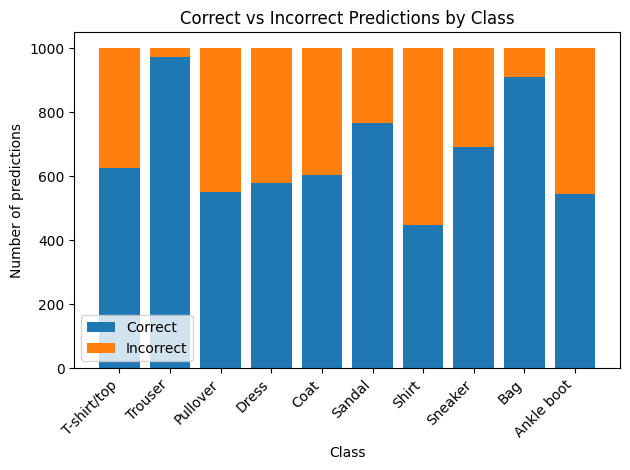

In [29]:


class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

_,_,_,_,_,_,_,_,_,a5_test = forward_pass(
    w1,b1,w2,b2,w3,b3,w4,b4,w5,b5,X_test
)

predictions = get_predictions(a5_test)
print(validate(predictions,y_test))

correct = predictions == y_test

correct_per_class = []
incorrect_per_class = []

for label in range(10):
    mask = y_test == label

    correct_per_class.append(np.sum(correct[mask]))
    incorrect_per_class.append(np.sum(~correct[mask]))

labels = np.arange(10)

plt.bar(labels, correct_per_class, label="Correct")
plt.bar(
    labels,
    incorrect_per_class,
    bottom=correct_per_class,
    label="Incorrect"
)

plt.xlabel("Class")
plt.ylabel("Number of predictions")
plt.title("Correct vs Incorrect Predictions by Class")

plt.xticks(labels, class_names, rotation=45, ha="right")

plt.legend()
plt.tight_layout()
plt.show()
